In [ ]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [ ]:
t_daily_range = df.T_DAILY_MAX-df.T_DAILY_MIN

In [ ]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

In [ ]:
fig,axes = plt.subplots(figsize=(15,20), nrows=3)
ax0,ax1,ax2 = axes
ax0.plot(date,t_daily_mean, color='purple', label= 'Daily Mean')
ax0.fill_between(date, t_daily_min, t_daily_max, color='0.8', label = 'Daily Range')
ax0.legend()
ax0.set_ylabel('Temperature [C]')
ax1.plot(date,p_daily_calc, color='cadetblue')
ax1.set_ylabel('Precipitation [mm/day]')
ax2.plot(date, soil_moisture_5, color='steelblue', label = '5 cm')
ax2.plot(date, soil_moisture_10, color='orange', label = '10 cm')
ax2.plot(date, soil_moisture_20, color='green', label = '20 cm')
ax2.plot(date, soil_moisture_50, color='red', label = '50 cm')
ax2.plot(date, soil_moisture_100, color='orchid', label = '100 cm')
ax2.legend()
ax2.set_ylabel('Soil Moisture [m$^3$/$m^3$]')

## Problem 2

In [ ]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

In [ ]:
fig,axes = plt.subplots(figsize=(20,10), ncols=2)
ax0,ax1 = axes

cf = ax0.contourf(lon, lat, temp, 15, cmap='magma')
ax0.contourf(lon,lat, temp, 15, cmap='magma');
ax0.set_xlabel('Longitude');
ax0.set_ylabel('Latitude');
ax0.set_title('Current Global Temperature');
fig.colorbar(cf ,ax=ax0, label= '°C')
ax0.contour(lon,lat,temp,2, cmap='binary')
idk = np.mean(temp, axis=1) 
ax1.plot(idk, lat, linewidth=5)
ax1.set_xlabel('°C')
ax1.set_title('Zonal Mean Temperature')

In [138]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

np.seterr(divide = 'ignore') 


filtered_list = [x for x in depth if x == x]

magnitude2 = (magnitude**4)/100

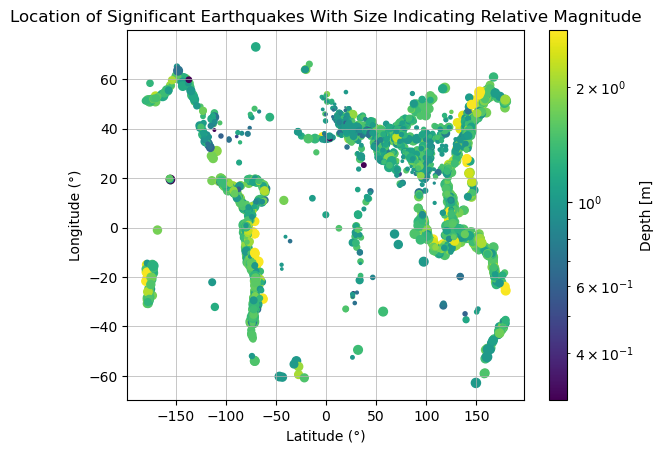

In [152]:
import matplotlib.colors as colors

fig, ax = plt.subplots()
splot = ax.scatter(longitude, latitude, c=np.log10(depth), s=magnitude2, norm=colors.LogNorm())
fig.colorbar(splot, label = 'Depth [m]')
ax.set_title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')
ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Longitude (°)')

ax.grid(which='minor', linestyle='dashed')
ax.grid(which='major',linewidth=0.5)
